<a href="https://colab.research.google.com/github/TEPPN/Animal-Classifier/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:  ultramilkk
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:17<00:00, 42.9MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cpu


In [3]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
1,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [4]:
train = data_df.sample(frac=0.7, random_state=42)
remaining = data_df.drop(train.index)

val = remaining.sample(frac=0.5, random_state=42)
test = remaining.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

# Transform untuk TRAINING (dengan augmentasi)
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Transform untuk VAL & TEST (tanpa augmentasi)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [6]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [7]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform_train)
test_dataset  = CustomImageDataset(dataframe=test,  transform=transform)
val_dataset   = CustomImageDataset(dataframe=val,   transform=transform)

In [8]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/wild/flickr_wild_002972.jpg


In [9]:
train_dataset.__getitem__(2)

(tensor([[[-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          ...,
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451]],
 
         [[-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          ...,
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451]],
 
         [[-0.9451, -0.9451, -0.9451,  ..., -0.9451, -0.9451, -0.9451],
          [-0.9451, -0.9451,

In [10]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

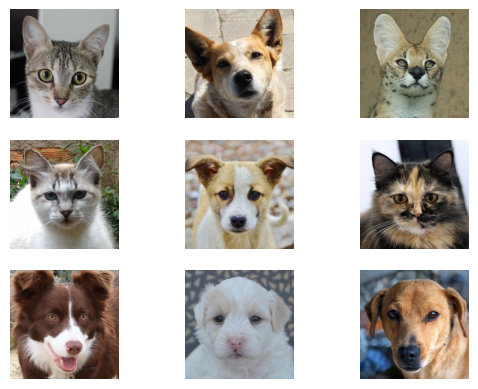

In [11]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [12]:
LR         = 1e-4
BATCH_SIZE = 32
EPOCHS     = 20

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [14]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pooling = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=0.4)

        self.flatten = nn.Flatten()
        self.linear  = nn.Linear(128 * 16 * 16, 256)
        self.dropout2 = nn.Dropout(p=0.4)
        self.output  = nn.Linear(256, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pooling(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pooling(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pooling(x)

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.relu(self.linear(x))
        x = self.dropout2(x)
        x = self.output(x)

        return x

In [15]:
model = Net().to(device)

In [16]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
      BatchNorm2d-10          [-1, 128, 32, 32]             256
             ReLU-11          [-1, 128, 32, 32]               0
        MaxPool2d-12          [-1, 128, 16, 16]               0
          Flatten-13                [-1, 32768]               0
          Dropout-14                [-1

In [17]:
criterion  = nn.CrossEntropyLoss()
optimizer  = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [ ]:
total_loss_train_plot      = []
total_loss_validation_plot = []
total_acc_train_plot       = []
total_acc_validation_plot  = []

# Early stopping config
best_val_loss   = float('inf')
patience        = 5
patience_counter = 0
best_model_path = '/content/best_model.pth'

for epoch in range(EPOCHS):
    model.train()
    total_acc_train  = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs    = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        optimizer.step()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

    model.eval()
    total_loss_val = 0
    total_acc_val  = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs  = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    avg_val_loss   = total_loss_val / len(val_loader)
    avg_train_loss = total_loss_train / len(train_loader)

    scheduler.step(avg_val_loss)

    total_loss_train_plot.append(round(avg_train_loss, 4))
    total_loss_validation_plot.append(round(avg_val_loss, 4))
    total_acc_train_plot.append(round((total_acc_train / len(train_dataset)) * 100, 4))
    total_acc_validation_plot.append(round((total_acc_val / len(val_dataset)) * 100, 4))

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {total_acc_train_plot[-1]:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {total_acc_validation_plot[-1]:.2f}%")

    # Early Stopping & simpan model terbaik
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ Model terbaik disimpan (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  ⚠️ No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("🛑 Early stopping triggered!")
            break

# Load kembali model terbaik
model.load_state_dict(torch.load(best_model_path))
print("✅ Model terbaik di-load kembali.")

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [ ]:
def predict_image(image_path):
  image = Image.open("/content/cat.jpg").convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [ ]:
predict_image("/content/cat.jpg")

In [ ]:
import shutil
final_model_path = '/content/animal_classifier_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'label_encoder_classes': label_encoder.classes_,
    'num_classes': len(data_df['labels'].unique())
}, final_model_path)

print(f"✅ Model tersimpan di: {final_model_path}")

from google.colab import files
files.download(final_model_path)